# Migration 09: Full-Cohort Regional BAG Predictions + Evaluation

This notebook generates regional Brain Age Gap (BAG) predictions for the **entire
available cohort** (not just the 12-session anat+diffusion intersection used in
`migration_07_multivariate_bag.ipynb`), and visualizes model performance.

## Cohort coverage in this demo store

The brainlink metadata covers **46 sessions / 42 subjects**, but the pre-parcellated
derivatives available in this demo store are smaller:

- **Anatomical** (CAT12, with TIV): **12 sessions / 9 subjects**
- **Diffusion** (DSIStudio, AMICONODDI, ...): **22 sessions / 19 subjects**
- **Anatomical ∩ Diffusion** (used in `migration_07`): 12 sessions / 9 subjects

`RegionalBAGEstimator` (univariate) requires TIV as a covariate, so it is bound to
the 12-session anatomical cohort. `MultivariateRegionalBAGEstimator` does not
require TIV, so combining **diffusion-only** features lets us predict BAG for the
full **22-session / 19-subject** cohort - the entire cohort with usable derivatives
in this store.

This notebook:
1. Runs multivariate BAG estimation on the full 22-session diffusion cohort.
2. Runs univariate per-region BAG estimation on the 12-session anatomical (TIV-complete) cohort.
3. Visualizes predicted-vs-actual age, BAG distributions, age-bias, and per-region quality.
4. Saves both results to the feature store (same layout the CLI's `--run-bag-estimation` produces).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from neuroalign.data.preprocessing import FeatureStore
from neuroalign.modeling import BAGConfig, MultivariateRegionalBAGEstimator, RegionalBAGEstimator

sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
store = FeatureStore(project_root / "data" / "processed" / "migration_demo")

meta = store.load_metadata()
print(f"Metadata: {len(meta)} sessions, {meta['uid'].nunique()} subjects")

diffusion_features = ["DSIStudio_tensor_fa_mean", "DSIStudio_tensor_md_mean", "AMICONODDI_noddi_icvf_modulated_mean"]
for name in diffusion_features + ["anat_thickness_mean_mm"]:
    df = store.load_feature(name, include_metadata=False)
    print(f"{name}: {df.shape[0]} sessions, {df['uid'].nunique()} subjects")

Metadata: 46 sessions, 42 subjects
DSIStudio_tensor_fa_mean: 22 sessions, 19 subjects
DSIStudio_tensor_md_mean: 22 sessions, 19 subjects
AMICONODDI_noddi_icvf_modulated_mean: 22 sessions, 19 subjects
anat_thickness_mean_mm: 12 sessions, 9 subjects


## 1. Multivariate BAG - full diffusion cohort (22 sessions / 19 subjects)

Combine three diffusion metrics (FA, MD, NODDI ICVF) per region via
`MultivariateRegionalBAGEstimator`. No TIV dependency, so all 22 sessions
with diffusion derivatives are used.

In [ ]:
bag_config = BAGConfig(age_col="AGE", n_splits=5, random_state=42)

multivariate = MultivariateRegionalBAGEstimator(bag_config)
multi_result = multivariate.fit_predict(store, diffusion_features)

multi_df = (
    multi_result.predicted_age
    .merge(multi_result.bag, on=["uid", "session_id"], suffixes=("", "_corrected"))
    .merge(multi_result.bag_uncorrected, on=["uid", "session_id"], suffixes=("", "_uncorrected"))
    .merge(meta[["uid", "session_id", "AGE", "sex"]], on=["uid", "session_id"], how="left")
    .rename(columns={"bag": "bag", "bag_uncorrected": "bag_uncorrected"})
)

print(f"Full-cohort predictions: {len(multi_df)} sessions / {multi_df['uid'].nunique()} subjects")
multi_df[["uid", "session_id", "AGE", "predicted_age", "bag_uncorrected", "bag"]].head()

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Outer folds:  80%|████████  | 4/5 [00:10<00:02,  2.59s/it]

## 2. Model performance overview

MAE:  3.29 years
R2:   -0.234
corr: 0.019


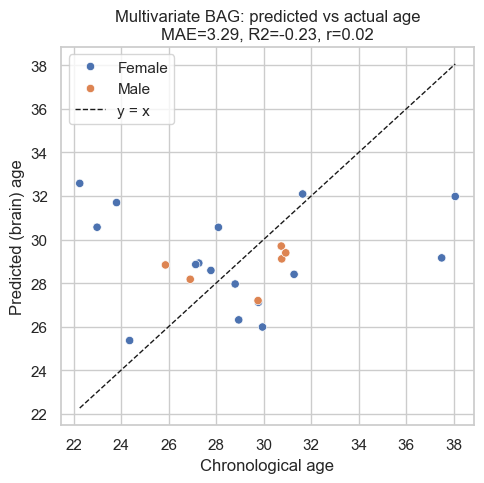

In [3]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

age = multi_df["AGE"].to_numpy()
pred = multi_df["predicted_age"].to_numpy()

mae = mean_absolute_error(age, pred)
r2 = r2_score(age, pred)
corr = pearsonr(age, pred)[0]

print(f"MAE:  {mae:.2f} years")
print(f"R2:   {r2:.3f}")
print(f"corr: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=multi_df, x="AGE", y="predicted_age", hue="sex", ax=ax)
age_range = [multi_df["AGE"].min(), multi_df["AGE"].max()]
ax.plot(age_range, age_range, "k--", lw=1, label="y = x")
ax.set_xlabel("Chronological age")
ax.set_ylabel("Predicted (brain) age")
ax.set_title(f"Multivariate BAG: predicted vs actual age\nMAE={mae:.2f}, R2={r2:.2f}, r={corr:.2f}")
ax.legend()
fig.tight_layout()

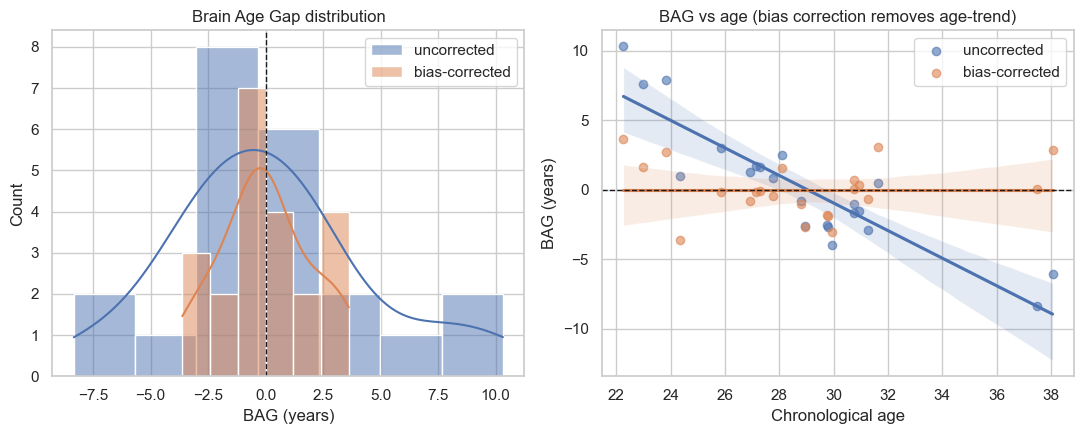

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(multi_df["bag_uncorrected"], ax=axes[0], color="C0", label="uncorrected", kde=True, alpha=0.5)
sns.histplot(multi_df["bag"], ax=axes[0], color="C1", label="bias-corrected", kde=True, alpha=0.5)
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].set_xlabel("BAG (years)")
axes[0].set_title("Brain Age Gap distribution")
axes[0].legend()

sns.regplot(data=multi_df, x="AGE", y="bag_uncorrected", ax=axes[1], label="uncorrected", color="C0", scatter_kws={"alpha": 0.6})
sns.regplot(data=multi_df, x="AGE", y="bag", ax=axes[1], label="bias-corrected", color="C1", scatter_kws={"alpha": 0.6})
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Chronological age")
axes[1].set_ylabel("BAG (years)")
axes[1].set_title("BAG vs age (bias correction removes age-trend)")
axes[1].legend()

fig.tight_layout()

## 3. Per-region diagnostics

`region_metrics` reports out-of-fold stage-1 (base learner) diagnostics for
each region from a full-data fit - useful for identifying which regions carry
the most age-related signal.

count    432.000000
mean      -0.708066
std        0.515516
min       -3.081309
25%       -0.969468
50%       -0.635570
75%       -0.398423
max        0.320386
Name: r2, dtype: float64

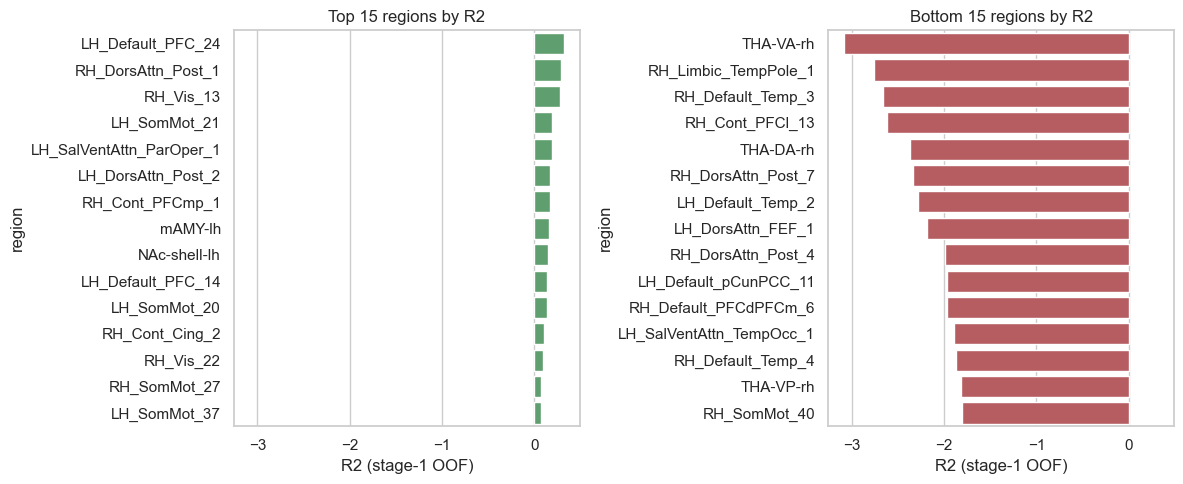

In [5]:
top_regions = multi_result.region_metrics.sort_values("r2", ascending=False).head(15)
bottom_regions = multi_result.region_metrics.sort_values("r2", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.barplot(data=top_regions, y="region", x="r2", ax=axes[0], color="C2")
axes[0].set_title("Top 15 regions by R2")
axes[0].set_xlabel("R2 (stage-1 OOF)")

sns.barplot(data=bottom_regions, y="region", x="r2", ax=axes[1], color="C3")
axes[1].set_title("Bottom 15 regions by R2")
axes[1].set_xlabel("R2 (stage-1 OOF)")

fig.tight_layout()

multi_result.region_metrics["r2"].describe()

## 4. Univariate per-region BAG - TIV-complete cohort (12 sessions / 9 subjects)

`RegionalBAGEstimator` fits one model per region (metric + sex + TIV ->
chronological age). It requires TIV as a covariate, so it is limited to the
12-session anatomical cohort. We use it here for region-level
interpretability on cortical thickness, complementing the full-cohort
multivariate model above.

In [6]:
features = store.load_feature("anat_thickness_mean_mm", include_metadata=False)
metadata = store.load_metadata().merge(store.load_tiv(), on=["uid", "session_id"], how="left")

uni_config = BAGConfig(
    age_col="AGE",
    sex_col="sex",
    tiv_col="tiv_mm3",
    subject_col="uid",
    session_col="session_id",
    n_splits=5,
    random_state=42,
)

univariate = RegionalBAGEstimator(uni_config)
uni_result = univariate.fit_predict(features, metadata)

print(f"Univariate BAG: {uni_result.bag.shape[0]} sessions x {uni_result.bag.shape[1] - 2} regions")
uni_result.region_metrics.sort_values("r2", ascending=False).head(10)

Fold 1/5:   0%|          | 0/400 [00:00<?, ?it/s]

Fold 2/5:   0%|          | 0/400 [00:00<?, ?it/s]

Fold 3/5:   0%|          | 0/400 [00:00<?, ?it/s]

Fold 4/5:   0%|          | 0/400 [00:00<?, ?it/s]

Fold 5/5:   0%|          | 0/400 [00:00<?, ?it/s]

Univariate BAG: 12 sessions x 400 regions


,region,r2,mae,correlation
9,7Networks_LH_Cont_PFCl_7,0.546185,2.119420,0.745441
203,7Networks_RH_Cont_PFCl_10,0.505161,3.105415,0.748530
330,7Networks_RH_SomMot_1,0.482980,2.695804,0.725260
272,7Networks_RH_DorsAttn_Post_1,0.482015,3.238455,0.733314
350,7Networks_RH_SomMot_28,0.354167,3.226285,0.635345
73,7Networks_LH_Default_pCunPCC_9,0.327298,3.130492,0.658581
237,7Networks_RH_Default_PFCdPFCm_4,0.323154,2.857736,0.645498
21,7Networks_LH_Cont_pCun_2,0.317069,3.509091,0.578891
135,7Networks_LH_SomMot_12,0.314416,3.209243,0.659377
281,7Networks_RH_DorsAttn_Post_18,0.259556,3.589882,0.632709


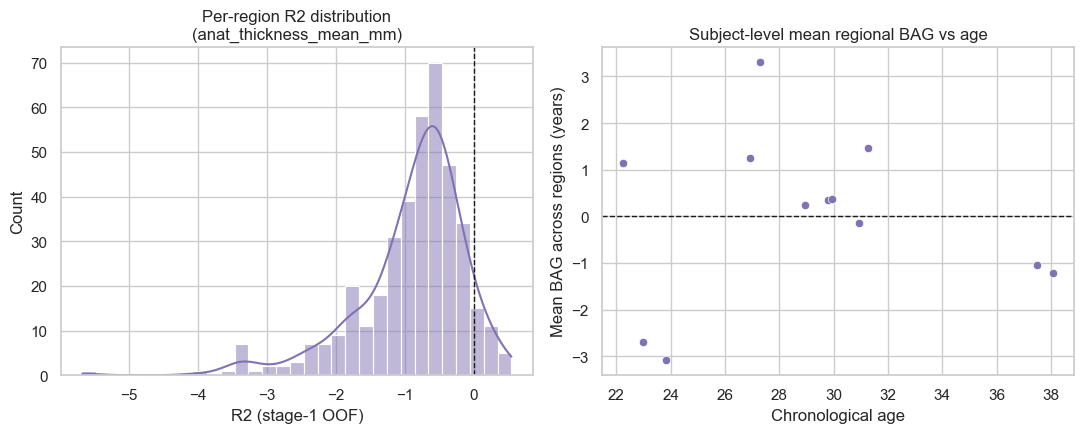

In [7]:
region_cols = [c for c in uni_result.bag.columns if c not in ("uid", "session_id")]

mean_bag = uni_result.bag[region_cols].mean(axis=1)
mean_bag_df = uni_result.bag[["uid", "session_id"]].copy()
mean_bag_df["mean_bag"] = mean_bag
mean_bag_df = mean_bag_df.merge(metadata[["uid", "session_id", "AGE"]], on=["uid", "session_id"], how="left")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(uni_result.region_metrics["r2"], ax=axes[0], color="C4", kde=True)
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].set_xlabel("R2 (stage-1 OOF)")
axes[0].set_title("Per-region R2 distribution\n(anat_thickness_mean_mm)")

sns.scatterplot(data=mean_bag_df, x="AGE", y="mean_bag", ax=axes[1], color="C4")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Chronological age")
axes[1].set_ylabel("Mean BAG across regions (years)")
axes[1].set_title("Subject-level mean regional BAG vs age")

fig.tight_layout()

## 5. Save results

Save both `BAGResult`s into the feature store, using the same layout produced
automatically by `neuroalign-prepare --run-bag-estimation` (Phase 9):

```
data/processed/migration_demo/bag/
├── univariate/anat_thickness_mean_mm/
└── multivariate/DSIStudio_tensor_fa_mean_DSIStudio_tensor_md_mean_AMICONODDI_noddi_icvf_modulated_mean/
```

In [8]:
multi_out_dir = store.root_dir / "bag" / "multivariate" / "_".join(diffusion_features)
uni_out_dir = store.root_dir / "bag" / "univariate" / "anat_thickness_mean_mm"

multi_result.save(multi_out_dir)
uni_result.save(uni_out_dir)

print(f"Saved multivariate (full cohort) BAG result to: {multi_out_dir}")
print(f"Saved univariate (TIV-complete cohort) BAG result to: {uni_out_dir}")

Saved multivariate (full cohort) BAG result to: /home/galkepler/Projects/neuroalign/data/processed/migration_demo/bag/multivariate/DSIStudio_tensor_fa_mean_DSIStudio_tensor_md_mean_AMICONODDI_noddi_icvf_modulated_mean
Saved univariate (TIV-complete cohort) BAG result to: /home/galkepler/Projects/neuroalign/data/processed/migration_demo/bag/univariate/anat_thickness_mean_mm


## Summary

- **Full-cohort predictions** (22 sessions / 19 subjects) generated via
  `MultivariateRegionalBAGEstimator` on diffusion-only features - nearly double
  the 12-session intersection used in `migration_07_multivariate_bag.ipynb`.
- **Per-region diagnostics** (`region_metrics`) identify which regions carry
  age-related signal for both the multivariate (diffusion) and univariate
  (anatomical thickness) models.
- BAG bias correction removes the age-trend visible in `bag_uncorrected`.
- Results are saved in the same `bag/<univariate|multivariate>/<feature(s)>/`
  layout that the CLI now generates automatically with
  `neuroalign-prepare --run-bag-estimation` (see Phase 9).